# 🍽️ Zomato Restaurant Analysis (Professional EDA)

## Project Highlights
- Data Cleaning & Preprocessing
- Missing Value Analysis
- Restaurant Type Analysis
- Rating Distribution
- Online Ordering Impact
- Cost Analysis
- Correlation Analysis
- Business Insights & Recommendations

**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn


Step 1: Importing necessary Python libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Zomato-data-.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (148, 7)


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


Step 2: Data Cleaning and Preparation

In [7]:
def clean_rating(value):
    try:
        return float(str(value).split('/')[0])
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rating)

print(df.info())
print("\nMissing Values:")
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB
None

Missing Values:


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Step 3: Exploring Restaurant Types

1. Listed_in (type) column to identify popular restaurant categories.

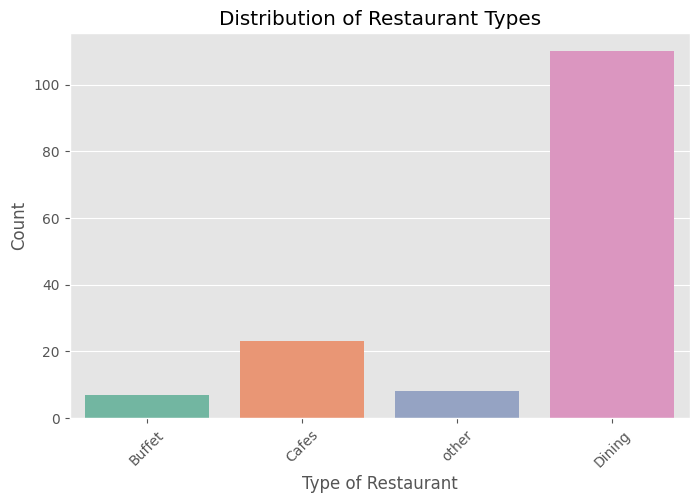

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['listed_in(type)'],
    hue=df['listed_in(type)'],
    palette='Set2',
    legend=False
)


plt.xlabel("Type of Restaurant")
plt.ylabel("Count")
plt.title("Distribution of Restaurant Types")
plt.xticks(rotation=45)

plt.show()

Conclusion: The majority of the restaurants fall into the dining category.

2. Votes by Restaurant Type

  --Here we get the count of votes for each category.--

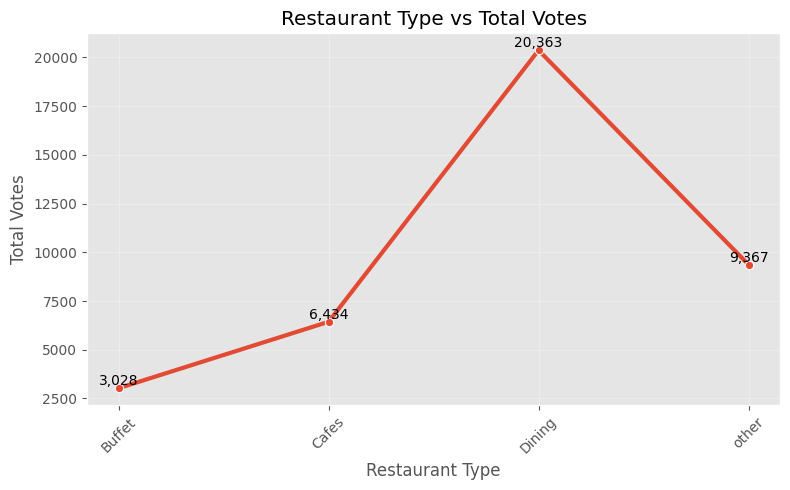

In [46]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

plt.figure(figsize=(8,5))

ax = sns.lineplot(
    x=grouped_data.index,
    y=grouped_data.values,
    marker='o',
    linewidth=3
)

plt.title('Restaurant Type vs Total Votes')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

for i, value in enumerate(grouped_data.values):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Conclusion: Dining restaurants are preferred by a larger number of individuals.

Step 4: Identifying the Most Voted Restaurant

In [27]:
top_restaurants = df.nlargest(10, 'votes')[['name','votes','rate']]
display(top_restaurants)

,name,votes,rate
38,Empire Restaurant,4884,4.4
86,Meghana Foods,4401,4.4
7,Onesta,2556,4.6
44,Onesta,2556,4.6
65,Kabab Magic,1720,4.1
37,Szechuan Dragon,1647,4.2
54,Roving Feast,1047,4.0
2,San Churro Cafe,918,3.8
14,San Churro Cafe,918,3.8
67,Gustoes Beer House,868,4.1


Step 5: Online Order Availability

 --Exploring the online_order column to see how many restaurants accept online orders.--

Text(0, 0.5, 'Count')

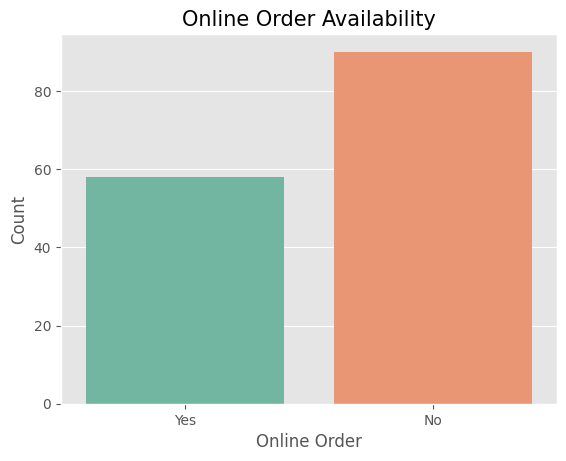

In [48]:
sns.countplot(
    x='online_order',
    data=df,
    hue='online_order',
    palette='Set2',
    legend=False
)

plt.title("Online Order Availability",fontsize=15)
plt.xlabel("Online Order")
plt.ylabel("Count")

Conclusion: This suggests that a majority of the restaurants do not accept online orders.

Step 5: Checking the distribution of ratings from the rate column.

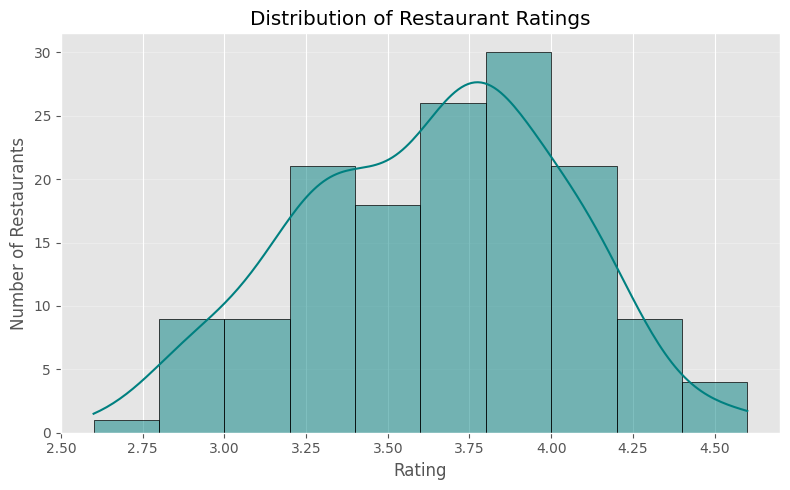

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['rate'],
    bins=10,
    kde=True,
    color='teal',
    edgecolor='black'
)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4.

Step 7 :Analyzing the approx_cost(for two people) column to find the preferred price range.

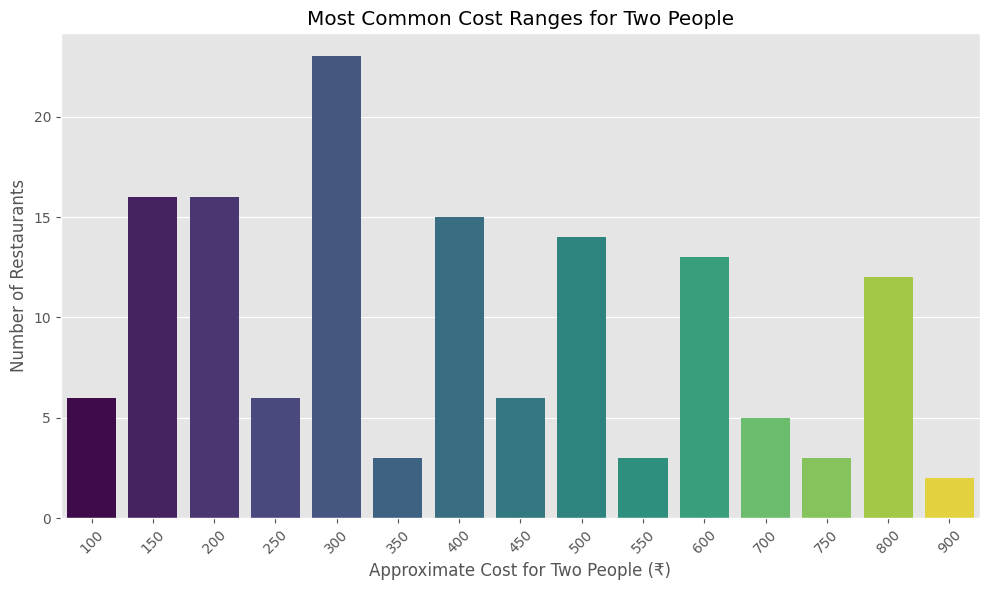

In [51]:
top_costs = df['approx_cost(for two people)'].value_counts().head(15)

plot_df = top_costs.reset_index()
plot_df.columns = ['Cost', 'Count']

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    x='Cost',
    y='Count',
    hue='Cost',
    palette='viridis',
    legend=False
)

plt.title('Most Common Cost Ranges for Two People')
plt.xlabel('Approximate Cost for Two People (₹)')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)
plt.tight_layout()


Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

Step 8 :Comparing ratings between restaurants that accept online orders and those that don't.

<Axes: xlabel='online_order', ylabel='rate'>

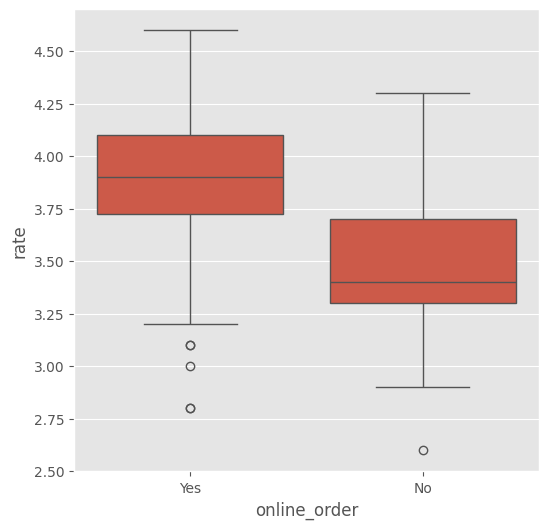

In [ ]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

Conclusion: Offline orders received lower ratings in comparison to online orders which obtained excellent ratings.

Step 9: Order Mode Preferences by Restaurant Type

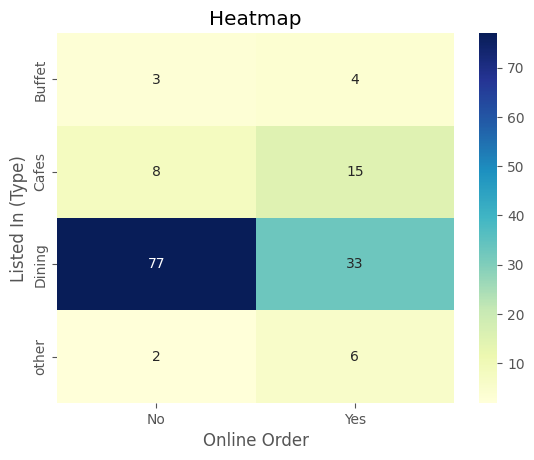

In [52]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.